# DAG
A directed acyclic graph (DAG) is a directed graph with no directed cycles, and can be used to represent our assumptions about how variables may causally influence one another. In a DAG:
- Nodes represent variables
- Arrows represent assumed causal relationships
- A DAG is **_NOT_** estimated from the data. It represents the causal argument based on theory and context.

## DAG Example: Government R&D Funding and Innovation

**Research question:** Does receiving government R&D funding increase a firm's innovation?

### Treatment and Outcome
- **Treatment:** Government R&D Funding
- **Outcome:** Innovation


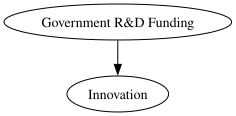

In [5]:
from graphviz import Digraph
from IPython.display import display

dag = Digraph()

dag.node("F", "Government R&D Funding")
dag.node("I", "Innovation")

dag.edge("F", "I")

display(dag)

### Confounding

Larger firms may be more likely to:

1. Receive government R&D funding, and
2. Produce innovations.

Therefore, **Firm Size** may be a confounder.

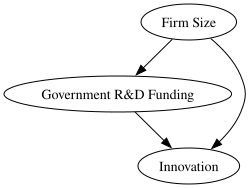

In [6]:
dag = Digraph()

dag.node("S", "Firm Size")
dag.node("F", "Government R&D Funding")
dag.node("I", "Innovation")

dag.edge("S", "F")
dag.edge("S", "I")
dag.edge("F", "I")

display(dag)

### Mediation

Government funding may also affect innovation by allowing firms to invest more in R&D.

Therefore, **R&D Investment** may be a mediator:

**Government R&D Funding → R&D Investment → Innovation**

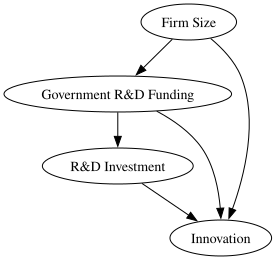

In [7]:
dag = Digraph()

dag.node("S", "Firm Size")
dag.node("F", "Government R&D Funding")
dag.node("R", "R&D Investment")
dag.node("I", "Innovation")

dag.edge("S", "F")
dag.edge("S", "I")

dag.edge("F", "R")
dag.edge("R", "I")

dag.edge("F", "I")

display(dag)

### Collider Bias

Suppose firms can also win a prestigious **Innovation Award**.

A firm may be more likely to win the award if:

1. It receives government R&D funding, or
2. It produces highly innovative products.

This creates the following structure:

**Government R&D Funding → Winning Innovation Award ← Innovation**

Winning Innovation Award is a **collider** because two arrows point into it.

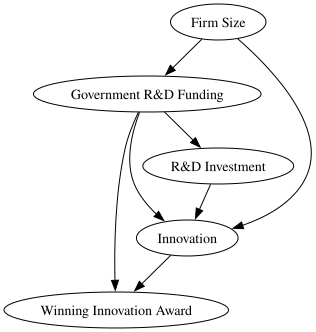

In [8]:
dag = Digraph()

dag.node("S", "Firm Size")
dag.node("F", "Government R&D Funding")
dag.node("R", "R&D Investment")
dag.node("I", "Innovation")
dag.node("A", "Winning Innovation Award")

# Confounding
dag.edge("S", "F")
dag.edge("S", "I")

# Main causal relationship
dag.edge("F", "I")

# Mediation
dag.edge("F", "R")
dag.edge("R", "I")

# Collider
dag.edge("F", "A")
dag.edge("I", "A")

display(dag)

#### Should we control for Winning Innovation Award?

Usually, **no**.

The path

**Government R&D Funding → Winning Innovation Award ← Innovation**

is naturally blocked because Winning Innovation Award is a collider.

However, if we condition on the collider — for example, by:

- controlling for winning an innovation award in a regression, or
- analyzing only firms that won an innovation award,

we can open this path and create a spurious association between government funding
and innovation.

This is called **collider bias** or **selection bias**.

## Discussion

Suppose our goal is to estimate the **total causal effect** of government R&D funding
on innovation.

Our dataset contains:

- Government R&D Funding
- Innovation
- Firm Size
- R&D Investment
- Winning Innovation Award

### Question

Which variables should we control for?

1. Firm Size?
2. R&D Investment?
3. Winning Innovation Award?

Why?